In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Zadanie 1 – Aproksymacja średniokwadratowa punktowa populacji USA

In [3]:
years = np.array([1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980], dtype=float)
population = np.array([76212168, 92228496, 106021537, 123202624,
                        132164569, 151325798, 179323175, 203302031, 226542199], dtype=float)

true_1990 = 248709873.0
n = len(years)

t_center = 1940.0
t_scale = 40.0
t = (years - t_center) / t_scale
t_1990 = (1990.0 - t_center) / t_scale


### (a) Aproksymacja wielomianami stopnia m = 0, 1, ..., 6 i ekstrapolacja do 1990

In [4]:
def fit_polynomial_ls(t_data, y_data, m):
    A = np.vander(t_data, N=m + 1, increasing=True)
    c, residuals, rank, sv = np.linalg.lstsq(A, y_data, rcond=None)
    return c


def eval_polynomial(c, t_eval):
    result = np.zeros_like(np.asarray(t_eval, dtype=float))
    for coeff in reversed(c):
        result = result * np.asarray(t_eval, dtype=float) + coeff
    return result


t_plot = np.linspace(t[0], t_1990, 300)
years_plot = t_plot * t_scale + t_center

print(f"{'m':>3}  {'Ekstrapolacja 1990':>20}  {'Prawdziwa':>15}  {'Błąd wzgl. [%]':>15}")
print("-" * 60)

results = {}
for m in range(7):
    c = fit_polynomial_ls(t, population, m)
    pred_1990 = eval_polynomial(c, t_1990)
    rel_err = abs(pred_1990 - true_1990) / true_1990 * 100
    results[m] = {'coeff': c, 'pred_1990': pred_1990, 'rel_err': rel_err}
    print(f"{m:>3}  {pred_1990:>20.0f}  {true_1990:>15.0f}  {rel_err:>14.4f}%")

best_m = min(results, key=lambda m: results[m]['rel_err'])
print(f"\nNajmniejszy błąd względny dla m = {best_m}: {results[best_m]['rel_err']:.4f}%")

  m    Ekstrapolacja 1990        Prawdziwa   Błąd wzgl. [%]
------------------------------------------------------------
  0             143369177        248709873         42.3549%
  1             235808109        248709873          5.1875%
  2             254712945        248709873          2.4137%
  3             261439380        248709873          5.1182%
  4             243106971        248709873          2.2528%
  5             220442802        248709873         11.3655%
  6             255044185        248709873          2.5469%

Najmniejszy błąd względny dla m = 4: 2.2528%


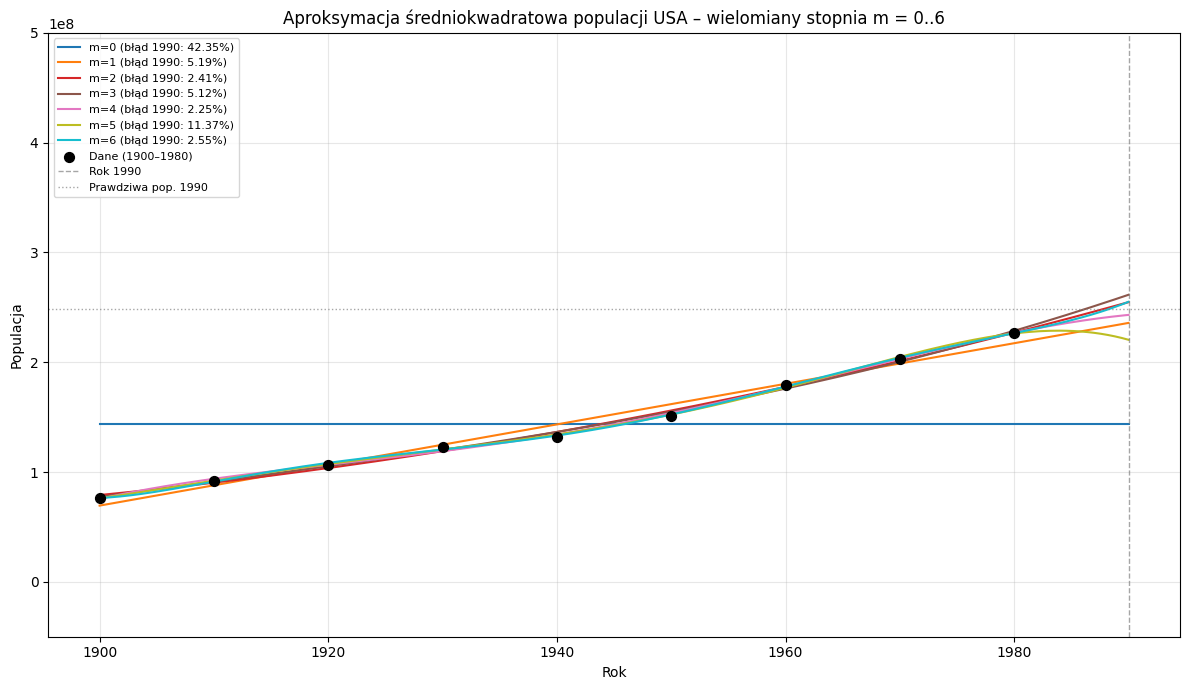

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.tab10(np.linspace(0, 1, 7))
for m in range(7):
    c = results[m]['coeff']
    y_plot = eval_polynomial(c, t_plot)
    ax.plot(years_plot, y_plot, color=colors[m], linewidth=1.5,
            label=f'm={m} (błąd 1990: {results[m]["rel_err"]:.2f}%)')

ax.scatter(years, population, color='black', zorder=10, s=50, label='Dane (1900–1980)')
ax.axvline(x=1990, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Rok 1990')
ax.axhline(y=true_1990, color='gray', linestyle=':', linewidth=1, alpha=0.7, label=f'Prawdziwa pop. 1990')
ax.set_xlabel('Rok')
ax.set_ylabel('Populacja')
ax.set_title('Aproksymacja średniokwadratowa populacji USA – wielomiany stopnia m = 0..6')
ax.legend(fontsize=8, loc='upper left')
ax.set_ylim(-5e7, 5e8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### (b) Kryterium informacyjne Akaikego (AICc) – wybór optymalnego stopnia

In [6]:
def compute_aicc(t_data, y_data, m):
    k = m + 1
    n_pts = len(y_data)
    
    c = fit_polynomial_ls(t_data, y_data, m)
    y_hat = eval_polynomial(c, t_data)
    
    sse = np.sum((y_data - y_hat) ** 2)
    mse = sse / n_pts
    
    aic = 2 * k + n_pts * np.log(mse)
    
    denom = n_pts - k - 1
    if denom <= 0:
        aicc = np.inf
    else:
        aicc = aic + 2 * k * (k + 1) / denom
    
    return aicc, sse, mse


print(f"{'m':>3}  {'k=m+1':>6}  {'n/k':>6}  {'SSE':>15}  {'AIC':>12}  {'AICc':>12}")
print("-" * 65)

aicc_values = {}
for m in range(7):
    k = m + 1
    aicc, sse, mse = compute_aicc(t, population, m)
    aicc_values[m] = aicc

    aic_val = 2 * k + n * np.log(mse)
    nk_ratio = n / k
    aicc_str = f"{aicc:12.2f}" if not np.isinf(aicc) else "        inf"
    print(f"{m:>3}  {k:>6}  {nk_ratio:>6.2f}  {sse:>15.4e}  {aic_val:>12.2f}  {aicc_str}")

valid = {m: v for m, v in aicc_values.items() if not np.isinf(v)}
best_m_aicc = min(valid, key=valid.get)
print(f"\nNajmniejsze AICc dla m = {best_m_aicc} (AICc = {aicc_values[best_m_aicc]:.2f})")
print(f"Najmniejszy błąd ekstrapolacji dla m = {best_m}")
print(f"\nCzy się pokrywają? {'TAK' if best_m_aicc == best_m else 'NIE'}")

  m   k=m+1     n/k              SSE           AIC          AICc
-----------------------------------------------------------------
  0       1    9.00       2.0918e+16        320.44        321.01
  1       2    4.50       4.1031e+14        287.06        289.06
  2       3    3.00       8.2812e+13        274.65        279.45
  3       4    2.25       6.8005e+13        274.88        284.88
  4       5    1.80       3.5102e+13        270.93        290.93
  5       6    1.50       2.3347e+13        269.26        311.26
  6       7    1.29       1.8709e+13        269.27        381.27

Najmniejsze AICc dla m = 2 (AICc = 279.45)
Najmniejszy błąd ekstrapolacji dla m = 4

Czy się pokrywają? NIE


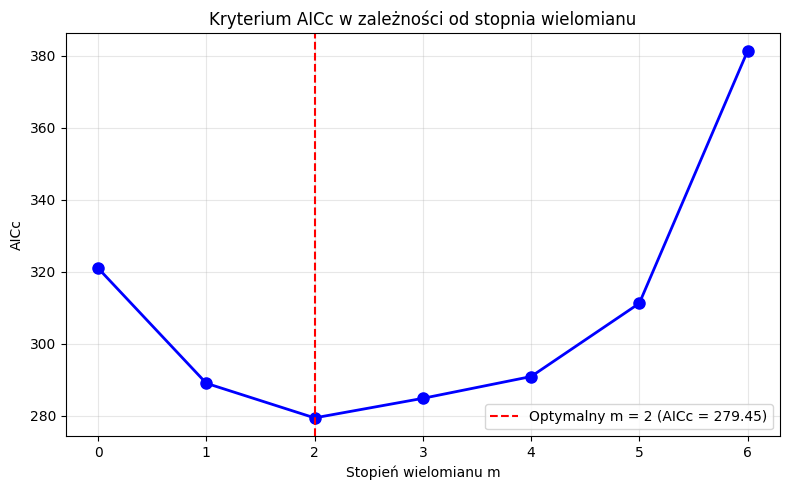

In [7]:
ms = list(valid.keys())
aicc_vals = [valid[m] for m in ms]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ms, aicc_vals, 'b-o', markersize=8, linewidth=2)
ax.axvline(x=best_m_aicc, color='red', linestyle='--', linewidth=1.5,
           label=f'Optymalny m = {best_m_aicc} (AICc = {aicc_values[best_m_aicc]:.2f})')
ax.set_xlabel('Stopień wielomianu m')
ax.set_ylabel('AICc')
ax.set_title('Kryterium AICc w zależności od stopnia wielomianu')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Zadanie 2 – Aproksymacja ciągła f(x) = √x wielomianami Czebyszewa

In [8]:
def chebyshev_T(k, t):
    if k == 0:
        return np.ones_like(t, dtype=float)
    elif k == 1:
        return np.asarray(t, dtype=float).copy()
    else:
        T_prev2 = np.ones_like(t, dtype=float)
        T_prev1 = np.asarray(t, dtype=float).copy()
        for _ in range(2, k + 1):
            T_curr = 2 * t * T_prev1 - T_prev2
            T_prev2 = T_prev1
            T_prev1 = T_curr
        return T_curr


def f(x):
    return np.sqrt(x)


N_quad = 500
j_idx = np.arange(1, N_quad + 1)
theta_j = (2 * j_idx - 1) * np.pi / (2 * N_quad)
t_j = np.cos(theta_j)
x_j = t_j + 1
f_j = f(x_j)

deg = 2
c = np.zeros(deg + 1)
c[0] = np.sum(f_j) / N_quad
for k in range(1, deg + 1):
    c[k] = 2.0 / N_quad * np.sum(f_j * np.cos(k * theta_j))

print("Współczynniki aproksymacji Czebyszewa (c_0, c_1, c_2):")
for k, ck in enumerate(c):
    print(f"  c_{k} = {ck:.10f}")

x_plot = np.linspace(0, 2, 500)
t_plot2 = x_plot - 1
p_approx = sum(c[k] * chebyshev_T(k, t_plot2) for k in range(deg + 1))

A0 = c[0] - c[2] - c[1] + 2 * c[2]
A1 = c[1] - 4 * c[2]
A2 = 2 * c[2]
print(f"\nAproksymant w postaci standardowej (coeffy przy 1, x, x^2):")
print(f"  p(x) = {A0:.8f} + {A1:.8f}*x + {A2:.8f}*x²")

Współczynniki aproksymacji Czebyszewa (c_0, c_1, c_2):
  c_0 = 0.9003166864
  c_1 = 0.6002101370
  c_2 = -0.1200414350

Aproksymant w postaci standardowej (coeffy przy 1, x, x^2):
  p(x) = 0.18006511 + 1.08037588*x + -0.24008287*x²


In [9]:
f_true = f(x_plot)
error = np.abs(f_true - p_approx)

print(f"Maksymalny błąd bezwzględny ||f - p||_inf = {np.max(error):.2e}")
print(f"Błąd L2 = {np.sqrt(np.trapz((f_true - p_approx)**2, x_plot)):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x_plot, f_true, 'k-', linewidth=2, label=r'$f(x) = \sqrt{x}$')
ax.plot(x_plot, p_approx, 'r--', linewidth=2,
        label=f'Aproksymant Czebyszewa m=2\n$p(x) = {A0:.4f} + {A1:.4f}x + {A2:.4f}x^2$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Aproksymacja $f(x)=\sqrt{x}$ wielomianem 2. stopnia (baza Czebyszewa)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_plot, error, 'b-', linewidth=2, label='Błąd bezwzględny |f(x) - p(x)|')
ax.set_xlabel('x')
ax.set_ylabel('Błąd bezwzględny')
ax.set_title('Błąd aproksymacji')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Aproksymacja ciągła średniokwadratowa z wagą Czebyszewa', fontsize=13)
plt.tight_layout()
plt.show()

Maksymalny błąd bezwzględny ||f - p||_inf = 1.80e-01


AttributeError: module 'numpy' has no attribute 'trapz'

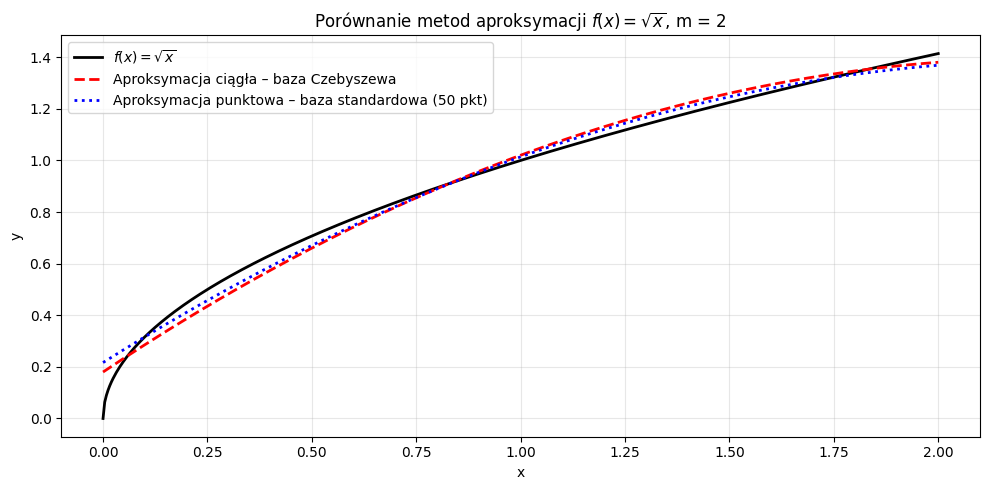

Błąd max aproksymacji Czebyszewa:         1.800651e-01
Błąd max aproksymacji standardowej (LS):  2.167283e-01


In [ ]:
x_nodes = np.linspace(0, 2, 50)
y_nodes = f(x_nodes)
A_std = np.vander(x_nodes, N=3, increasing=True)
c_std, _, _, _ = np.linalg.lstsq(A_std, y_nodes, rcond=None)
p_std = c_std[0] + c_std[1] * x_plot + c_std[2] * x_plot**2

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_plot, f_true, 'k-', linewidth=2, label=r'$f(x) = \sqrt{x}$')
ax.plot(x_plot, p_approx, 'r--', linewidth=2, label='Aproksymacja ciągła – baza Czebyszewa')
ax.plot(x_plot, p_std, 'b:', linewidth=2, label='Aproksymacja punktowa – baza standardowa (50 pkt)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Porównanie metod aproksymacji $f(x) = \sqrt{x}$, m = 2')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

err_cheb = np.max(np.abs(f_true - p_approx))
err_std  = np.max(np.abs(f_true - p_std))
print(f"Błąd max aproksymacji Czebyszewa:         {err_cheb:.6e}")
print(f"Błąd max aproksymacji standardowej (LS):  {err_std:.6e}")